Colonnes : ['Patient', 'Gest_age_weeks', 'Category', 'Aspirin', 'Gravida', 'Fertility_treatment', 'BMI', 'Race', 'Sex', 'IUGR']
Shape : (363, 10)
Shape X_train : (257, 8)
Shape X_test : (106, 8)


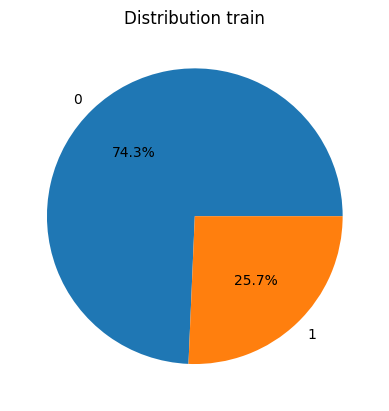

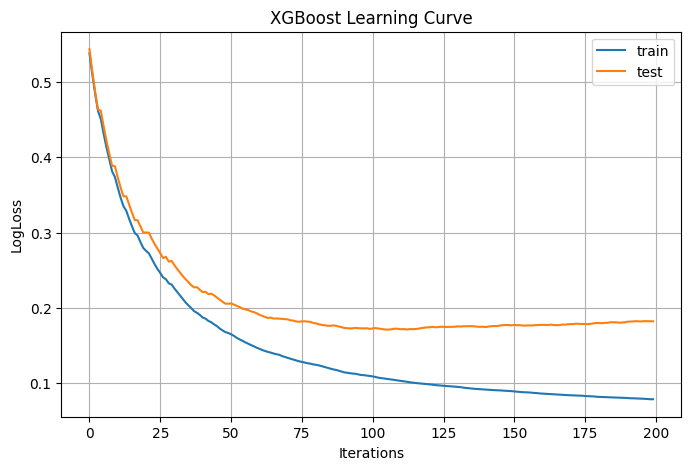


Top 10 variables importantes :
IUGR                   0.681017
Aspirin                0.075309
Gest_age_weeks         0.049026
Fertility_treatment    0.045431
Gravida                0.044087
Race                   0.038641
BMI                    0.034373
Sex                    0.032115
dtype: float32


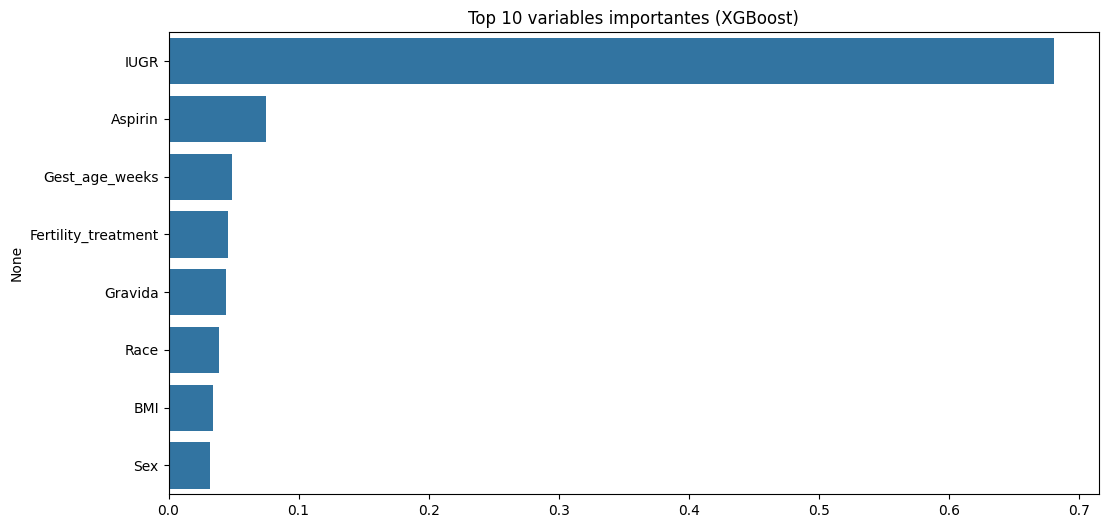


Accuracy entraînement : 0.9727626459143969
Accuracy test : 0.9433962264150944

Matrice de confusion :
[[77  1]
 [ 5 23]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.94      0.99      0.96        78
           1       0.96      0.82      0.88        28

    accuracy                           0.94       106
   macro avg       0.95      0.90      0.92       106
weighted avg       0.94      0.94      0.94       106



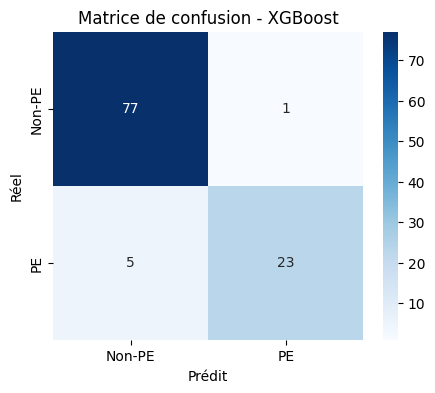


Sensibilité (Recall) : 0.8214285714285714
Spécificité : 0.9871794871794872
False Positive Rate : 0.01282051282051282
AUC : 0.9551282051282051


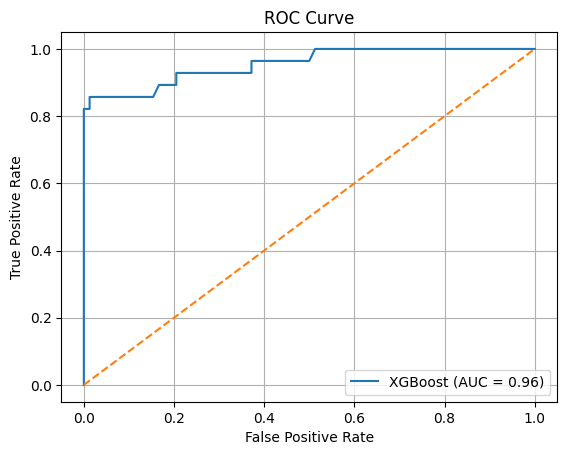

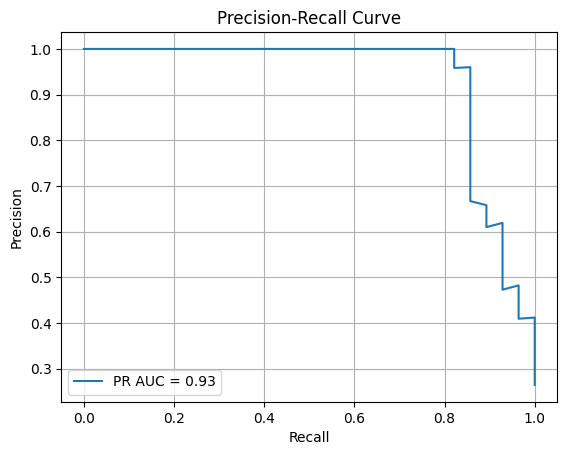

Cross-validation AUC : 0.9390688259109312


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_recall_curve,
    auc as pr_auc
)

# ==============================
# 1. LOAD DATA
# ==============================
df = pd.read_excel("preprocessed_preeclampsia 1.xlsx")

df.columns = df.columns.str.strip()

print("Colonnes :", df.columns.tolist())
print("Shape :", df.shape)

# ==============================
# 2. NETTOYAGE
# ==============================
df["BMI"] = df["BMI"].astype(str).str.replace(",", ".").astype(float)

# ==============================
# 3. TARGET
# ==============================
target_col = "Category"
df[target_col] = df[target_col].astype(int)

# ==============================
# 4. SPLIT PAR PATIENT
# ==============================
patients = df["Patient"].unique()

train_patients, test_patients = train_test_split(
    patients,
    test_size=0.3,
    random_state=42
)

train_df = df[df["Patient"].isin(train_patients)]
test_df = df[df["Patient"].isin(test_patients)]

# ==============================
# 5. X / y
# ==============================
X_train = train_df.drop(columns=[target_col, "Patient"])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col, "Patient"])
y_test = test_df[target_col]

# ==============================
# 6. ENCODAGE
# ==============================
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Shape X_train :", X_train.shape)
print("Shape X_test :", X_test.shape)

# ==============================
# 7. VISUALISATION
# ==============================
plt.figure()
y_train.value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Distribution train")
plt.ylabel("")
plt.show()

# ==============================
# 8. MODEL XGBOOST
# ==============================
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

# ==============================
# 9. LEARNING CURVE
# ==============================
results = model.evals_result()

plt.figure(figsize=(8,5))
plt.plot(results['validation_0']['logloss'], label="train")
plt.plot(results['validation_1']['logloss'], label="test")
plt.xlabel("Iterations")
plt.ylabel("LogLoss")
plt.title("XGBoost Learning Curve")
plt.legend()
plt.grid()
plt.show()

# ==============================
# 10. FEATURE IMPORTANCE
# ==============================
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print("\nTop 10 variables importantes :")
print(feat_imp.head(10))

plt.figure(figsize=(12,6))
sns.barplot(x=feat_imp.values[:10], y=feat_imp.index[:10])
plt.title("Top 10 variables importantes (XGBoost)")
plt.show()

# ==============================
# 11. PREDICTIONS
# ==============================
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)
y_proba = model.predict_proba(X_test)[:, 1]

# ==============================
# 12. METRICS
# ==============================
print("\nAccuracy entraînement :", accuracy_score(y_train, y_train_pred))
print("Accuracy test :", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nMatrice de confusion :")
print(cm)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

# ==============================
# 13. MATRICE DE CONFUSION (GRAPH)
# ==============================
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-PE", "PE"],
            yticklabels=["Non-PE", "PE"])

plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title("Matrice de confusion - XGBoost")
plt.show()

# ==============================
# 14. METRICS MEDICALES
# ==============================
tn, fp, fn, tp = cm.ravel()

sensibilite = recall_score(y_test, y_pred)
specificite = tn / (tn + fp)
fpr_value = fp / (fp + tn)

print("\nSensibilité (Recall) :", sensibilite)
print("Spécificité :", specificite)
print("False Positive Rate :", fpr_value)

# ==============================
# 15. ROC CURVE
# ==============================
auc_score = roc_auc_score(y_test, y_proba)
print("AUC :", auc_score)

fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {auc_score:.2f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# ==============================
# 16. PRECISION-RECALL CURVE
# ==============================
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_score = pr_auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC = {pr_score:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

# ==============================
# 17. CROSS-VALIDATION
# ==============================
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
print("Cross-validation AUC :", cv_scores.mean())